In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:



# Load cleaned dataset
df = pd.read_csv("cleaned_data/customer_data_cleaned.csv")

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape:
(10088, 15)

First 5 Rows:
  Client_Num  Customer_Age  Gender  Dependent_Count Education_Level  \
0    C100000            29     NaN                1      Uneducated   
1    C100001            25    Male                1         College   
2    C100002            58    Male                0   Post-Graduate   
3    C100003            52    Male                4         College   
4    C100004            50  Female                1         College   

  Marital_Status state_cd  Zipcode Car_Owner House_Owner Personal_loan  \
0        Unknown       NY    87903       Yes          No           Yes   
1       Divorced       TX    42795        No          No           Yes   
2         Single       GA    83043        No         Yes            No   
3         Single       IL    55803       Yes          No           Yes   
4        Unknown       OH    89811        No         Yes           Yes   

     contact   Customer_Job    Income  Cust_Satisfaction_Score  
0   Cellular        S

In [3]:
# Basic statistics of Customer data

# This gives you important statistics such as:

# -Average customer age
# -Minimum and maximum age
# -Average income
# -Median income
# -Satisfaction score
# -Number of customers
print("\n===== BASIC STATISTICS =====")

print("\nNumerical Summary:")
print(df.describe())

print("\nAverage Age:")
print(df["Customer_Age"].mean())

print("\nAverage Income:")
print(df["Income"].mean())

print("\nMedian Income:")
print(df["Income"].median())

print("\nAverage Satisfaction Score:")
print(df["Cust_Satisfaction_Score"].mean())



===== BASIC STATISTICS =====

Numerical Summary:
       Customer_Age  Dependent_Count       Zipcode         Income  \
count  10088.000000     10088.000000  10088.000000   10088.000000   
mean      45.037173         2.474722  55086.068101   99071.526566   
std       14.030604         1.706290  26148.899979   46527.353894   
min       21.000000         0.000000  10004.000000   -1000.000000   
25%       33.000000         1.000000  32089.500000   59583.000000   
50%       45.000000         2.000000  54906.000000   98617.000000   
75%       57.000000         4.000000  77663.500000  139462.750000   
max       69.000000         5.000000  99996.000000  179995.000000   

       Cust_Satisfaction_Score  
count             10088.000000  
mean                  3.034596  
std                   1.412001  
min                   1.000000  
25%                   2.000000  
50%                   3.000000  
75%                   4.000000  
max                   5.000000  

Average Age:
45.03717287866772

In [5]:
# Analyze Gender
print("\n==== GENDER ANALYSIS ====")
print(df["Gender"].value_counts())
      


==== GENDER ANALYSIS ====
Gender
Female    5030
Male      4979
Name: count, dtype: int64


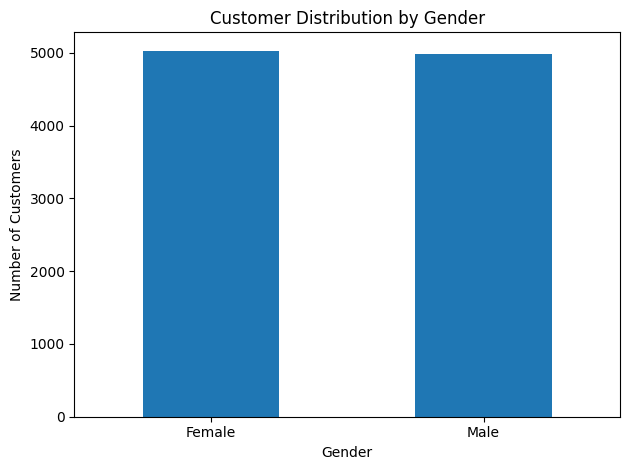

In [7]:
df["Gender"].value_counts().plot(kind="bar")

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
# Customer Job Analysis
print("\n===== CUSTOMER JOB ANALYSIS =====")
print(df["Customer_Job"].value_counts())


===== CUSTOMER JOB ANALYSIS =====
Customer_Job
Government       1514
Businessman      1467
Self-employed    1434
Retired          1432
Salaried         1421
Student          1389
Unemployed       1371
Name: count, dtype: int64


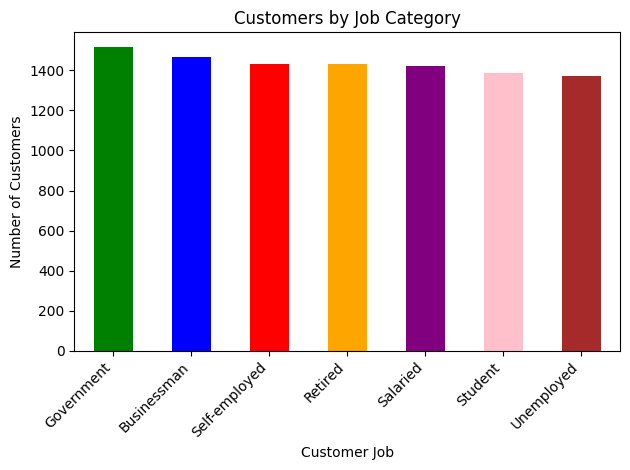

In [11]:
df["Customer_Job"].value_counts().plot(
    kind="bar",
    color=["green", "blue", "red", "orange", "purple", "pink", "brown", "cyan"]
)

plt.title("Customers by Job Category")
plt.xlabel("Customer Job")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [12]:
# Education Level Analysis
print("\n===== EDUCATION ANALYSIS =====")
print(df["Education_Level"].value_counts())


===== EDUCATION ANALYSIS =====
Education_Level
High School      2045
College          2026
Graduate         2025
Uneducated       1981
Post-Graduate    1941
Name: count, dtype: int64


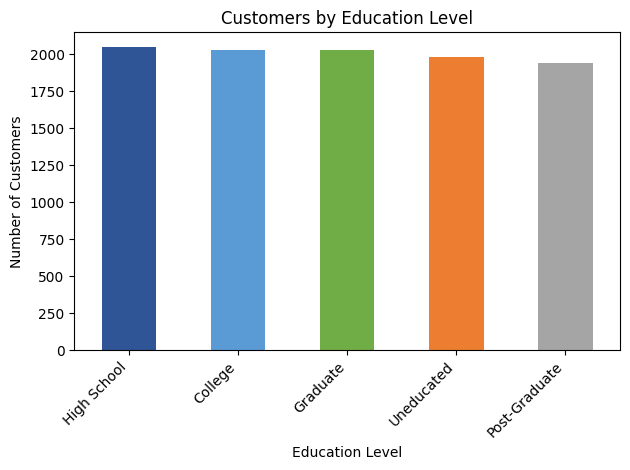

In [14]:
df["Education_Level"].value_counts().plot(
    kind="bar",
    color=["#2F5597", "#5B9BD5", "#70AD47", "#ED7D31", "#A5A5A5", "#FFC000"]
)

plt.title("Customers by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

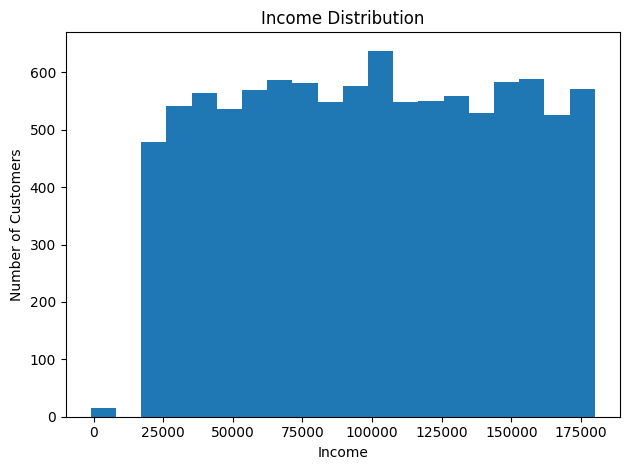

In [15]:
# Income Distribution
plt.hist(df["Income"], bins=20)

plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

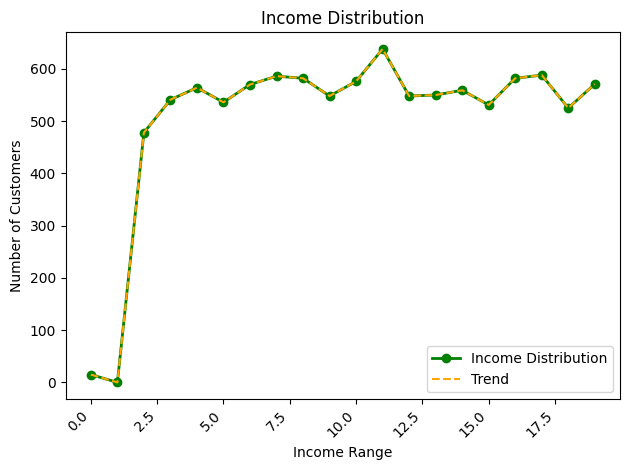

In [17]:


# Create income ranges
income_bins = pd.cut(df["Income"], bins=20)

# Count customers in each income range
income_counts = income_bins.value_counts().sort_index()

plt.plot(
    range(len(income_counts)),
    income_counts.values,
    color="green",
    marker="o",
    linewidth=2,
    label="Income Distribution"
)

plt.plot(
    range(len(income_counts)),
    income_counts.values,
    color="orange",
    linestyle="--",
    linewidth=1.5,
    label="Trend"
)

plt.title("Income Distribution")
plt.xlabel("Income Range")
plt.ylabel("Number of Customers")
plt.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

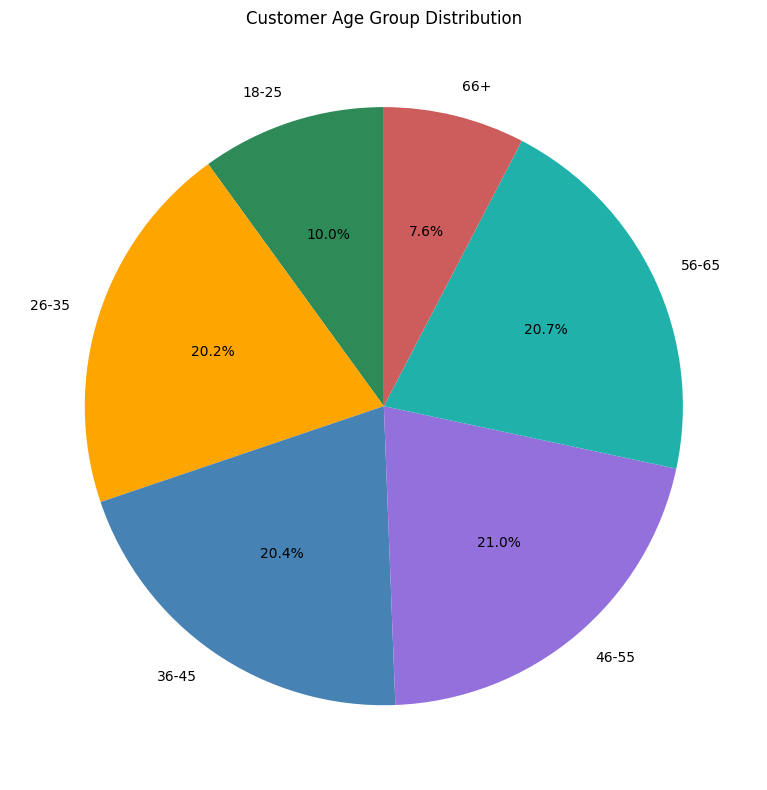

In [20]:


# Create age groups
age_groups = pd.cut(
    df["Customer_Age"],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]
)

# Count customers in each age group
age_counts = age_groups.value_counts().sort_index()

# Pie chart
plt.figure(figsize=(8, 8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#2E8B57", "#FFA500", "#4682B4", "#9370DB", "#20B2AA", "#CD5C5C"]
)

plt.title("Customer Age Group Distribution")
plt.tight_layout()
plt.show()

In [21]:
# Satisfaction Score
print("\n===== SATISFACTION ANALYSIS =====")
print(df["Cust_Satisfaction_Score"].value_counts().sort_index())



===== SATISFACTION ANALYSIS =====
Cust_Satisfaction_Score
1    1947
2    1968
3    2040
4    2055
5    2078
Name: count, dtype: int64


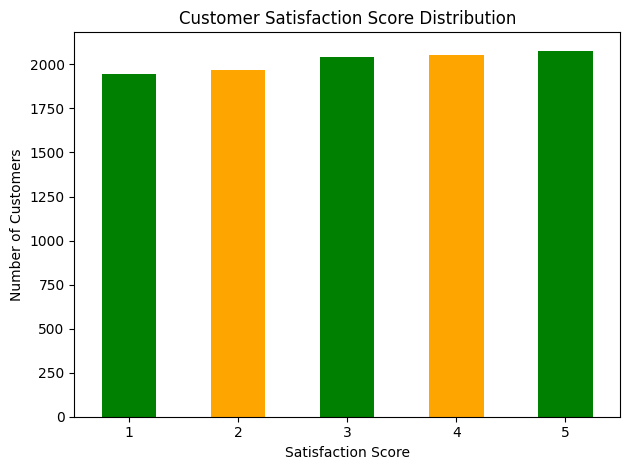

In [26]:
df["Cust_Satisfaction_Score"].value_counts().sort_index().plot(kind="bar",
                                                              color=["green",  "orange"])

plt.title("Customer Satisfaction Score Distribution")
plt.xlabel("Satisfaction Score")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [27]:
# Home and Car Ownership
print("\n===== CAR OWNERSHIP =====")
print(df["Car_Owner"].value_counts())

print("\n===== HOUSE OWNERSHIP =====")
print(df["House_Owner"].value_counts())


===== CAR OWNERSHIP =====
Car_Owner
No     5100
Yes    4953
YES      35
Name: count, dtype: int64

===== HOUSE OWNERSHIP =====
House_Owner
No     5118
Yes    4970
Name: count, dtype: int64


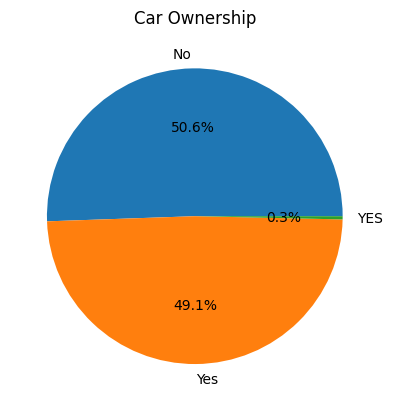

In [28]:
df["Car_Owner"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.title("Car Ownership")
plt.ylabel("")
plt.show()

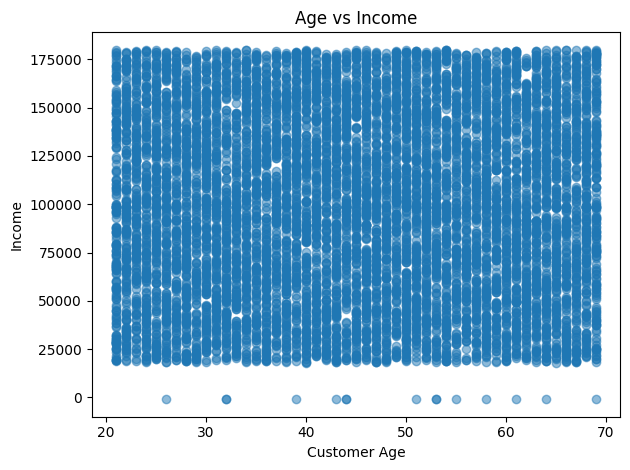

In [29]:
# Check relationship between Age and Income
plt.scatter(df["Customer_Age"], df["Income"], alpha=0.5)

plt.title("Age vs Income")
plt.xlabel("Customer Age")
plt.ylabel("Income")
plt.tight_layout()
plt.show()

In [30]:
# Find the top categories
print("\n===== TOP CATEGORIES =====")

print("\nMost Common Gender:")
print(df["Gender"].mode()[0])

print("\nMost Common Education Level:")
print(df["Education_Level"].mode()[0])

print("\nMost Common Job:")
print(df["Customer_Job"].mode()[0])

print("\nMost Common Marital Status:")
print(df["Marital_Status"].mode()[0])


===== TOP CATEGORIES =====

Most Common Gender:
Female

Most Common Education Level:
High School

Most Common Job:
Government

Most Common Marital Status:
Married


In [31]:
# Save the EDA statistics
summary = {
    "Total Customers": len(df),
    "Total Columns": len(df.columns),
    "Average Age": df["Customer_Age"].mean(),
    "Average Income": df["Income"].mean(),
    "Median Income": df["Income"].median(),
    "Average Satisfaction Score": df["Cust_Satisfaction_Score"].mean(),
    "Most Common Gender": df["Gender"].mode()[0],
    "Most Common Education": df["Education_Level"].mode()[0],
    "Most Common Job": df["Customer_Job"].mode()[0],
    "Most Common Marital Status": df["Marital_Status"].mode()[0]
}

summary_df = pd.DataFrame([summary])

summary_df.to_csv("reports/eda_summary.csv", index=False)

print("\nEDA summary saved successfully!")


EDA summary saved successfully!
